In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

In [2]:
# อ่านไฟล์ข้อมูล
df = pd.read_csv('data.csv')

# เลือก Feature (Weight และ Height)
feature_cols = ['Weight', 'Height']
X = df[feature_cols]

# สเกลข้อมูลด้วย StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("จำนวนข้อมูลทั้งหมด:", X_scaled.shape[0], "แถว")
df.head()

จำนวนข้อมูลทั้งหมด: 500 แถว


,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


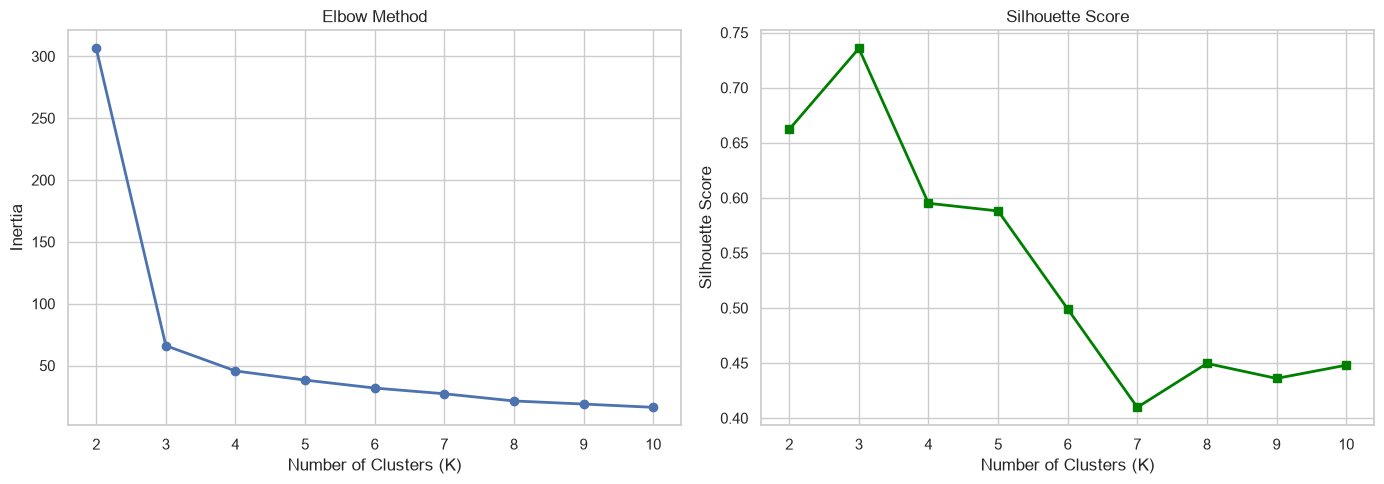

In [3]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# พล็อตกราฟเปรียบเทียบ
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(K_range, inertia, marker='o', color='b', linewidth=2)
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouette_scores, marker='s', color='green', linewidth=2)
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [4]:
# กำหนดค่า K ที่เหมาะสม (เช่น K = 3)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("จำนวนสมาชิกในแต่ละ Cluster:")
print(df['Cluster'].value_counts().sort_index())

จำนวนสมาชิกในแต่ละ Cluster:
Cluster
0    128
1    125
2    247
Name: count, dtype: int64


In [5]:
# ใช้ Cluster เป็น Target (y)
y = df['Cluster']

# แบ่งข้อมูล Train/Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# เทรนโมเดล SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# ประเมินผลโมเดล
y_pred = svm_model.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

SVM Accuracy: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        49

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



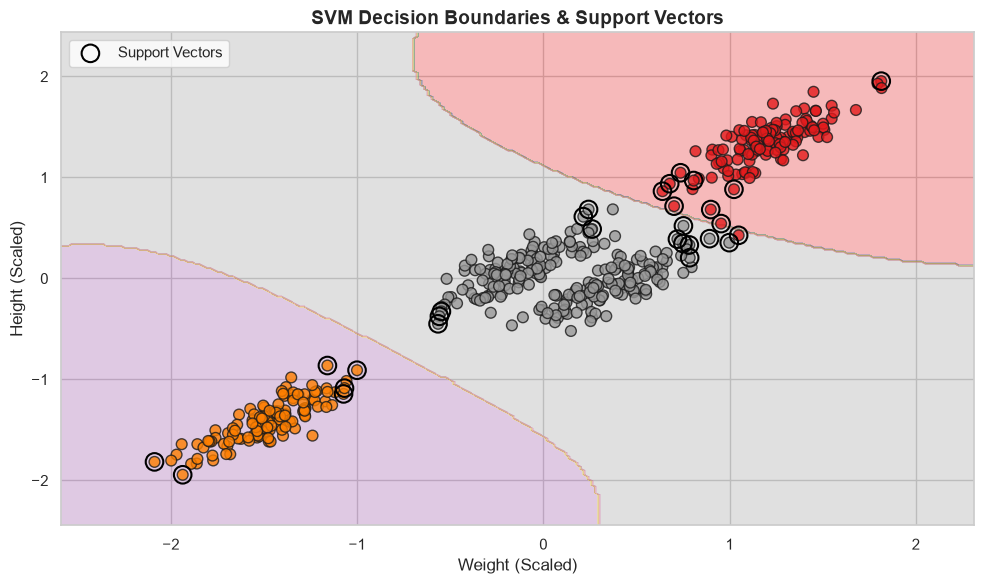

In [35]:
# สร้าง Meshgrid สำหรับวาด Decision Boundaries
h = .02
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# ทำนายค่าทุกจุดบน Grid
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

# 1. แรสีพื้นที่ Decision Boundaries
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')

# 2. พล็อตจุดข้อมูลจริง (ใช้ตัวแปร y ที่สร้างไว้)
scatter = plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1], 
    c=y, cmap='Set1', edgecolors='k', s=60, alpha=0.8
)

# 3. พล็อตจุด Support Vectors
plt.scatter(
    svm_model.support_vectors_[:, 0], 
    svm_model.support_vectors_[:, 1], 
    s=160, 
    facecolors='none', 
    edgecolors='black', 
    linewidths=1.5, 
    label='Support Vectors'
)

plt.title('SVM Decision Boundaries & Support Vectors', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Scaled)', fontsize=12)
plt.ylabel('Height (Scaled)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()